# 04 — Worst-case analysis

Created with Grok Build

Endpoint / corner analysis with:

| Variable | Range |
|----------|--------|
| Each $R$ | $\pm 0.1\%$ |
| Each $C$ | $\pm 1\%$ |
| $V_{OS}$ | $\pm 200\,\mu\mathrm{V}$ |
| $I_{B+}$, $I_{B-}$ | independently $\pm 10\,\mathrm{pA}$ |

**Metrics**

1. **Cutoff** $f_c$ (−3 dB)
2. **DC accuracy** for an applied voltage $V_{\mathrm{in,DC}}$: ideal unity-gain target
   $V_{\mathrm{out}}=V_{\mathrm{in,DC}}$, error
   $\varepsilon_{\mathrm{DC}}=V_{\mathrm{out}}-V_{\mathrm{in,DC}}$

Also reports **RSS** (root-sum-square of one-at-a-time half-spans) for comparison
with endpoint WC. Analytical corners + optional ngspice R/C AC corners.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory that contains opamp_design/. Works when this notebook is run
# from the standalone repo (repo root or notebooks/) or from this website
# section (the folder that holds these notebooks and opamp_design/).
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/OPA365_Fig86")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "opamp_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from opamp_design.params import CircuitParams, OpampParams, ToleranceSpec, format_eng
from opamp_design import analysis, schematic

# -----------------------------------------------------------------------------
# EDITABLE PARAMETERS — change R/C/tolerances here for what-if studies.
# For a completely different netlist, keep these as documentation of the
# stimulus/supply and drive opamp_design.simulate.run_external_netlist(...)
# with your own .cir instead of the Fig. 8-6 generators.
# -----------------------------------------------------------------------------
R1 = 1.8e3       # ohms
R2 = 19.5e3
R3 = 150e3
C1 = 3.3e-9      # farads
C2 = 47e-12
C3 = 220e-12
R_TOL = 0.001    # 0.1% as fraction
C_TOL = 0.01     # 1% as fraction
V_SUPPLY = 5.0
V_IN_BIAS = 2.5
V_IN_PEAK = 2.5
F_DESIGN = 20e3
# Applied DC voltage for accuracy analysis (unity-gain: target Vout = Vin)
VIN_DC = 2.5

p = CircuitParams(
    R1=R1, R2=R2, R3=R3, C1=C1, C2=C2, C3=C3,
    r_tol=ToleranceSpec(R_TOL),
    c_tol=ToleranceSpec(C_TOL),
)
from dataclasses import replace
p = replace(p, op=replace(p.op, v_supply=V_SUPPLY, v_in_bias=V_IN_BIAS,
                          v_in_peak=V_IN_PEAK, f_design_hz=F_DESIGN))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT =", ROOT)
print("R1..C3 =", p.passive_dict())
print("VIN_DC for accuracy =", VIN_DC, "V")


ROOT = .
R1..C3 = {'R1': 1800.0, 'R2': 19500.0, 'R3': 150000.0, 'C1': 3.3e-09, 'C2': 4.7e-11, 'C3': 2.2e-10}
VIN_DC for accuracy = 2.5 V


Applied DC Vin = 2.5 V  (ideal Vout = Vin)
Nominal fc      = 19766.713 Hz
WC fc           = [19550.257, 19990.109] Hz
RSS fc          = [19580.362, 19953.064] Hz  (±186.351)

Nominal dc_error = 0.000 µV
WC dc_error      = [-201.715, 201.715] µV
RSS dc_error     = [-200.007, 200.007] µV  (±200.007)


,metric,unit,nominal,WC min,WC max,RSS low,RSS high
0,fc (-3 dB),Hz,19766.713183,19550.256553,19990.109150,19580.362192,19953.064174
1,DC error (Vout - Vin),µV,0.000000,-201.714713,201.714713,-200.007336,200.007336
2,DC error,ppm,0.000000,-80.685885,80.685885,NaN,NaN
3,Vout @ Vin_DC,V,2.500000,2.499798,2.500202,NaN,NaN


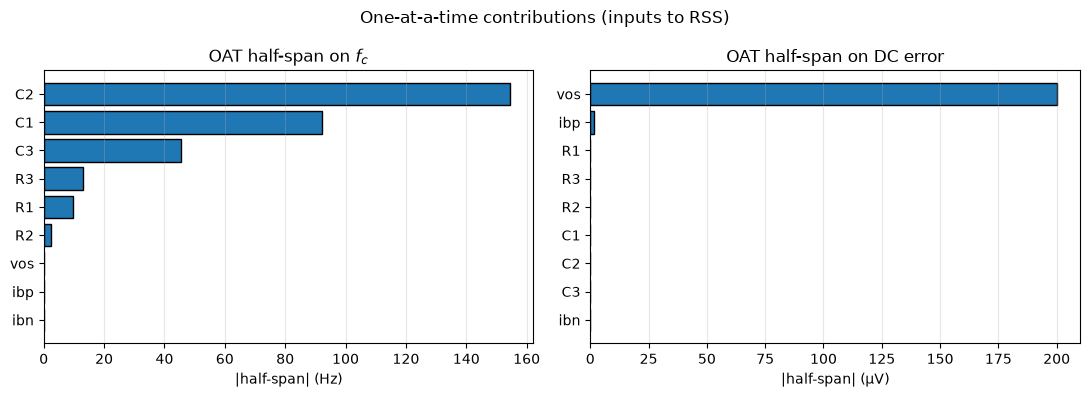

In [2]:
from opamp_design.worst_case import (
    analytical_worst_case,
    spice_wc_corners,
    rss_bounds,
    oat_contributions,
    dc_accuracy_vs_vin,
)

wc = analytical_worst_case(p, include_opamp=True, vin_dc=VIN_DC)
rss = rss_bounds(p, metrics=("fc_hz", "dc_error"), vin_dc=VIN_DC, include_opamp=True)
oat = oat_contributions(p, metrics=("fc_hz", "dc_error"), vin_dc=VIN_DC)

print(f"Applied DC Vin = {VIN_DC} V  (ideal Vout = Vin)")
print(f"Nominal fc      = {wc.nominal['fc_hz']:.3f} Hz")
print(f"WC fc           = [{wc.minimum['fc_hz']:.3f}, {wc.maximum['fc_hz']:.3f}] Hz")
print(f"RSS fc          = [{rss['fc_hz']['low']:.3f}, {rss['fc_hz']['high']:.3f}] Hz  (±{rss['fc_hz']['delta_rss']:.3f})")
print()
print(f"Nominal dc_error = {wc.nominal['dc_error']*1e6:.3f} µV")
print(f"WC dc_error      = [{wc.minimum['dc_error']*1e6:.3f}, {wc.maximum['dc_error']*1e6:.3f}] µV")
print(f"RSS dc_error     = [{rss['dc_error']['low']*1e6:.3f}, {rss['dc_error']['high']*1e6:.3f}] µV  (±{rss['dc_error']['delta_rss']*1e6:.3f})")

# Summary table: fc + DC accuracy
rows = []
for met, label, scale, unit in (
    ("fc_hz", "fc (-3 dB)", 1.0, "Hz"),
    ("dc_error", "DC error (Vout - Vin)", 1e6, "µV"),
    ("dc_error_ppm", "DC error", 1.0, "ppm"),
    ("dc_vout", "Vout @ Vin_DC", 1.0, "V"),
):
    if met not in wc.nominal:
        continue
    rows.append({
        "metric": label,
        "unit": unit,
        "nominal": wc.nominal[met] * scale,
        "WC min": wc.minimum[met] * scale,
        "WC max": wc.maximum[met] * scale,
        "RSS low": rss[met]["low"] * scale if met in rss else np.nan,
        "RSS high": rss[met]["high"] * scale if met in rss else np.nan,
    })
summary = pd.DataFrame(rows)
display(summary)

# OAT contribution bars (which params drive WC/RSS)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, met, title, scale, unit in (
    (axes[0], "fc_hz", r"OAT half-span on $f_c$", 1.0, "Hz"),
    (axes[1], "dc_error", r"OAT half-span on DC error", 1e6, "µV"),
):
    items = sorted(oat[met].items(), key=lambda kv: kv[1], reverse=True)
    names = [k for k, _ in items]
    vals = [v * scale for _, v in items]
    ax.barh(names[::-1], vals[::-1], color="C0", edgecolor="k")
    ax.set_xlabel(f"|half-span| ({unit})")
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
fig.suptitle("One-at-a-time contributions (inputs to RSS)")
fig.tight_layout()
fig.savefig(FIG / "04_wc_oat_contributions.png", dpi=150)
plt.show()


,vin_applied,dc_error_nom,dc_vout_nom,dc_error_wc_min,dc_error_wc_max,dc_vout_wc_min,dc_vout_wc_max,dc_error_ppm_nom
0,0.5,0.000000e+00,0.5,-0.000202,0.000202,0.499798,0.500202,0.000000e+00
1,1.0,0.000000e+00,1.0,-0.000202,0.000202,0.999798,1.000202,0.000000e+00
2,1.5,-4.440892e-16,1.5,-0.000202,0.000202,1.499798,1.500202,-2.960595e-10
3,2.0,0.000000e+00,2.0,-0.000202,0.000202,1.999798,2.000202,0.000000e+00
4,2.5,0.000000e+00,2.5,-0.000202,0.000202,2.499798,2.500202,0.000000e+00
5,3.0,-8.881784e-16,3.0,-0.000202,0.000202,2.999798,3.000202,-2.960595e-10
6,3.5,0.000000e+00,3.5,-0.000202,0.000202,3.499798,3.500202,0.000000e+00
7,4.0,0.000000e+00,4.0,-0.000202,0.000202,3.999798,4.000202,0.000000e+00
8,4.5,0.000000e+00,4.5,-0.000202,0.000202,4.499798,4.500202,0.000000e+00


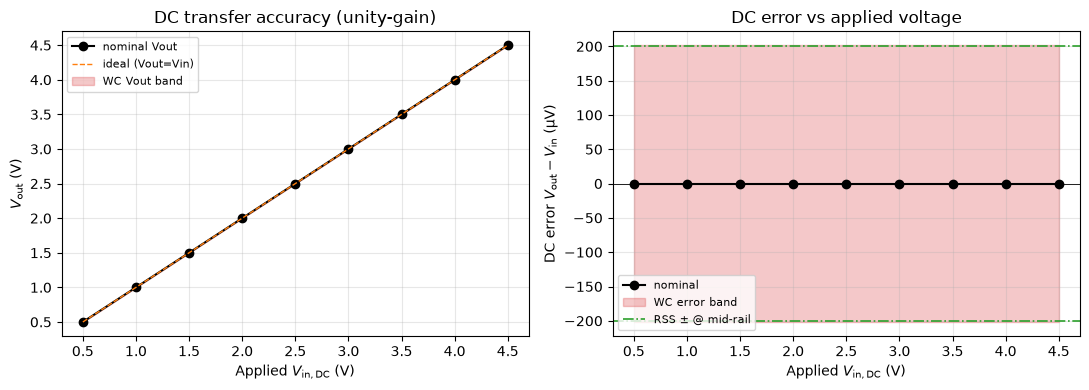

At Vin=2.5 V: WC |error| up to 201.71 µV; RSS |error| ≤ 200.01 µV


In [3]:
# DC accuracy vs applied Vin: nominal + WC envelope
dc_vs = dc_accuracy_vs_vin(p, include_opamp_wc=True)
display(dc_vs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Vout vs Vin with WC band
axes[0].plot(dc_vs.vin_applied, dc_vs.dc_vout_nom, "k-o", lw=1.5, label="nominal Vout")
axes[0].plot(dc_vs.vin_applied, dc_vs.vin_applied, "C1--", lw=1.0, label="ideal (Vout=Vin)")
axes[0].fill_between(
    dc_vs.vin_applied, dc_vs.dc_vout_wc_min, dc_vs.dc_vout_wc_max,
    color="C3", alpha=0.25, label="WC Vout band",
)
axes[0].set_xlabel(r"Applied $V_{\mathrm{in,DC}}$ (V)")
axes[0].set_ylabel(r"$V_{\mathrm{out}}$ (V)")
axes[0].set_title("DC transfer accuracy (unity-gain)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

# Error vs Vin with WC band
axes[1].axhline(0, color="k", lw=0.6)
axes[1].plot(dc_vs.vin_applied, dc_vs.dc_error_nom * 1e6, "k-o", lw=1.5, label="nominal")
axes[1].fill_between(
    dc_vs.vin_applied,
    dc_vs.dc_error_wc_min * 1e6,
    dc_vs.dc_error_wc_max * 1e6,
    color="C3", alpha=0.25, label="WC error band",
)
# RSS at mid-rail as annotation
axes[1].axhline(rss["dc_error"]["high"] * 1e6, color="C2", ls="-.", lw=1.2, label="RSS ± @ mid-rail")
axes[1].axhline(rss["dc_error"]["low"] * 1e6, color="C2", ls="-.", lw=1.2)
axes[1].set_xlabel(r"Applied $V_{\mathrm{in,DC}}$ (V)")
axes[1].set_ylabel(r"DC error $V_{\mathrm{out}}-V_{\mathrm{in}}$ (µV)")
axes[1].set_title("DC error vs applied voltage")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG / "04_wc_dc_accuracy_vs_vin.png", dpi=150)
plt.show()

print(
    f"At Vin={VIN_DC} V: WC |error| up to "
    f"{max(abs(wc.minimum['dc_error']), abs(wc.maximum['dc_error']))*1e6:.2f} µV; "
    f"RSS |error| ≤ {rss['dc_error']['delta_rss']*1e6:.2f} µV"
)


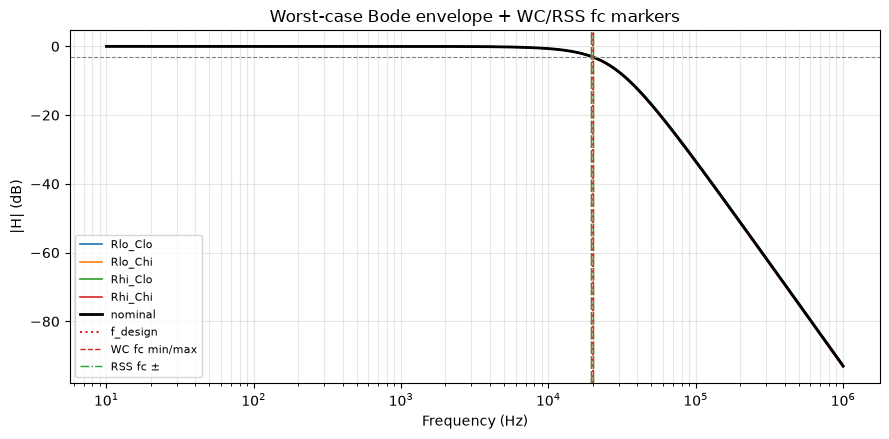

Lowest fc corners:


,corner,fc_hz,dc_error,dc_vout
4,R_hi_C_hi,19550.256553,-4.440892e-16,2.5
2,R_lo_C_hi,19589.229522,1.332268e-15,2.5
14,C2_hi,19614.644160,0.000000e+00,2.5
12,C1_hi,19675.081141,0.000000e+00,2.5
15,C3_lo,19720.947464,0.000000e+00,2.5


Highest |dc_error| corners:


,corner,fc_hz,dc_error,dc_vout
32,R_hi_vos=2.000e-04_ibp=1.000e-11,19746.638275,-0.000202,2.499798
29,R_hi_vos=-2.000e-04_ibp=-1.000e-11,19746.638275,0.000202,2.500202
23,op_vos=2.000e-04_ibp=1.000e-11_ibn=-1.000e-11,19766.713183,-0.000202,2.499798
24,op_vos=2.000e-04_ibp=1.000e-11_ibn=1.000e-11,19766.713183,-0.000202,2.499798
17,op_vos=-2.000e-04_ibp=-1.000e-11_ibn=-1.000e-11,19766.713183,0.000202,2.500202


In [4]:
# Bode envelope from R/C all-low / all-high (fc-focused)
from opamp_design.analysis import bode, frequency_grid
f = frequency_grid(10, 1e6, 301)
curves = {}
for r_side, c_side in [("lo", "lo"), ("lo", "hi"), ("hi", "lo"), ("hi", "hi")]:
    kw = {}
    for n in p.resistance_names():
        lo, hi = p.r_tol.bounds(getattr(p, n))
        kw[n] = lo if r_side == "lo" else hi
    for n in p.capacitance_names():
        lo, hi = p.c_tol.bounds(getattr(p, n))
        kw[n] = lo if c_side == "lo" else hi
    curves[f"R{r_side}_C{c_side}"] = bode(p.with_values(**kw), f_hz=f)

fig, ax = plt.subplots(figsize=(9, 4.5))
for name, br in curves.items():
    ax.semilogx(br.f_hz, br.mag_db, label=name, lw=1.2)
br0 = bode(p, f_hz=f)
ax.semilogx(br0.f_hz, br0.mag_db, "k-", lw=2, label="nominal")
ax.axhline(-3, color="gray", ls="--", lw=0.8)
ax.axvline(p.op.f_design_hz, color="C3", ls=":", label="f_design")
# WC / RSS fc markers on frequency axis
ax.axvline(wc.minimum["fc_hz"], color="C3", ls="--", lw=1.0, label="WC fc min/max")
ax.axvline(wc.maximum["fc_hz"], color="C3", ls="--", lw=1.0)
ax.axvline(rss["fc_hz"]["low"], color="C2", ls="-.", lw=1.0, label="RSS fc ±")
ax.axvline(rss["fc_hz"]["high"], color="C2", ls="-.", lw=1.0)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("|H| (dB)")
ax.set_title("Worst-case Bode envelope + WC/RSS fc markers")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "04_wc_bode_envelope.png", dpi=150)
plt.show()

# Extreme corners for fc and dc_error
fr = pd.DataFrame(wc.rows)
print("Lowest fc corners:")
display(fr.nsmallest(5, "fc_hz")[["corner", "fc_hz", "dc_error", "dc_vout"]])
print("Highest |dc_error| corners:")
fr2 = fr.assign(abs_err=fr.dc_error.abs())
display(fr2.nlargest(5, "abs_err")[["corner", "fc_hz", "dc_error", "dc_vout"]])


In [5]:
# Optional SPICE WC (ideal model) — R/C corners for fc
wd = ROOT / "results" / "ngspice_wc"
try:
    sp = spice_wc_corners(p, workdir=wd, root=ROOT, opamp_model="ideal")
    display(pd.DataFrame(sp))
except Exception as e:
    print("SPICE WC skipped/failed:", e)

# Persist WC/RSS summary for notebook 05 overlays
wc_export = {
    "vin_dc": VIN_DC,
    "fc_wc_min": wc.minimum["fc_hz"],
    "fc_wc_max": wc.maximum["fc_hz"],
    "fc_rss_low": rss["fc_hz"]["low"],
    "fc_rss_high": rss["fc_hz"]["high"],
    "fc_nom": wc.nominal["fc_hz"],
    "dc_err_wc_min": wc.minimum["dc_error"],
    "dc_err_wc_max": wc.maximum["dc_error"],
    "dc_err_rss_low": rss["dc_error"]["low"],
    "dc_err_rss_high": rss["dc_error"]["high"],
    "dc_err_nom": wc.nominal["dc_error"],
}
pd.Series(wc_export).to_json(ROOT / "results" / "wc_rss_summary.json")
print("Wrote results/wc_rss_summary.json for MC notebook overlays")


,corner,fc_spice_hz,fc_analytical_hz,params
0,R_lo_C_lo,19989.166133,19990.109150,"{'R1': 1798.2, 'R2': 19480.5, 'R3': 149850.0, ..."
1,R_lo_C_hi,19580.131307,19589.229522,"{'R1': 1798.2, 'R2': 19480.5, 'R3': 149850.0, ..."
2,R_hi_C_lo,19951.445687,19951.486895,"{'R1': 1801.7999999999997, 'R2': 19519.4999999..."
3,R_hi_C_hi,19540.204885,19550.256553,"{'R1': 1801.7999999999997, 'R2': 19519.4999999..."


Wrote results/wc_rss_summary.json for MC notebook overlays
